In [25]:
# Configuração: Imports e Setup dos Parâmetros
import sys
import os
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

# Adicionar path do projeto ao sys.path
project_root = Path.cwd()
sys.path.insert(0, str(project_root))

# Carregar os módulos de otimização
exec(open("otimizacao/A_definicao_parametros.py").read(), globals())
exec(open("otimizacao/B_condicoes_modelo.py").read(), globals())
exec(open("otimizacao/C_aproximacao_perdas.py").read(), globals())

# Importar função de visualização
from variaveis_otimizadas.otimo_viz import gerar_figuras

# Importar funções do main
from main import executar_otimizacao

# Constantes
CENARIOS = list(range(7))  # 0 a 6
CONJUNTO_INSTANCIAS_DIR = "conjuntos_instancias"
DIR_SAIDA = "variaveis_otimizadas"

print("✓ Setup concluído")
print(f"  Cenários a analisar: {CENARIOS}")
print(f"  Diretório de dados: {CONJUNTO_INSTANCIAS_DIR}")
print(f"  Diretório de saída: {DIR_SAIDA}")

✓ Setup concluído
  Cenários a analisar: [0, 1, 2, 3, 4, 5, 6]
  Diretório de dados: conjuntos_instancias
  Diretório de saída: variaveis_otimizadas


In [26]:
# Função de Orquestração: Executar Todos os Cenários
def executar_todos_cenarios(cenarios=CENARIOS, verbose=True):
    """
    Executa a otimização para todos os cenários de microrrede.
    
    Args:
        cenarios (list): Lista de índices dos cenários a executar (default: [0,1,2,3,4,5,6])
        verbose (bool): Se deve exibir logs detalhados
    
    Returns:
        list: Lista com dicionários de resultado para cada cenário
    """
    os.makedirs(DIR_SAIDA, exist_ok=True)
    resultados = []
    
    print(f"\n{'='*70}")
    print(f"EXECUTANDO {len(cenarios)} CENÁRIOS DE OTIMIZAÇÃO")
    print(f"{'='*70}\n")
    
    for idx_cenario in (tqdm(cenarios, desc="Cenários") if not verbose else cenarios):
        # Caminho do arquivo de entrada
        arquivo_entrada = f"{CONJUNTO_INSTANCIAS_DIR}/dados_microrrede_{idx_cenario}.csv"
        
        # Verificar se arquivo existe
        if not os.path.exists(arquivo_entrada):
            print(f"⚠ Arquivo não encontrado: {arquivo_entrada}")
            continue
        
        try:
            # Executar otimização
            resultado = executar_otimizacao(
                caminho_csv=arquivo_entrada,
                pasta_saida_figuras=str(idx_cenario)  # 0, 1, 2, ...
            )
            
            # Adicionar índice do cenário ao resultado
            resultado["cenario"] = idx_cenario
            resultados.append(resultado)
            
        except Exception as e:
            print(f"✗ Erro ao processar cenário {idx_cenario}: {str(e)}")
            continue
    
    print(f"\n{'='*70}")
    print(f"✓ Execução concluída: {len(resultados)}/{len(cenarios)} cenários processados")
    print(f"{'='*70}\n")
    
    return resultados


# Executar todos os cenários
print("Célula pronta para executar: resultados = executar_todos_cenarios()")

Célula pronta para executar: resultados = executar_todos_cenarios()


In [27]:
# Função de Consolidação: Combinar Resultados
def consolidar_resultados(cenarios=CENARIOS):
    """
    Consolida os resultados de todos os cenários em um único DataFrame.
    
    Args:
        cenarios (list): Lista de índices dos cenários
    
    Returns:
        pd.DataFrame: DataFrame consolidado com coluna 'cenario'
    """
    print("\n" + "="*70)
    print("CONSOLIDANDO RESULTADOS")
    print("="*70 + "\n")
    
    dataframes = []
    
    for idx_cenario in cenarios:
        arquivo_csv = f"{DIR_SAIDA}/variaveis_otimizadas_{idx_cenario}.csv"
        
        if not os.path.exists(arquivo_csv):
            print(f"⚠ Arquivo não encontrado: {arquivo_csv}")
            continue
        
        try:
            df = pd.read_csv(arquivo_csv)
            df["cenario"] = idx_cenario
            dataframes.append(df)
            print(f"  ✓ Carregado: {arquivo_csv} ({len(df)} linhas)")
        except Exception as e:
            print(f"  ✗ Erro ao carregar {arquivo_csv}: {str(e)}")
    
    # Concatenar todos os DataFrames
    if dataframes:
        df_consolidado = pd.concat(dataframes, ignore_index=True)
        print(f"\n✓ Consolidação concluída: {len(df_consolidado)} linhas totais")
        
        # Salvar consolidado
        arquivo_consolidado = f"{DIR_SAIDA}/variaveis_otimizadas_consolidado.csv"
        df_consolidado.to_csv(arquivo_consolidado, index=False)
        print(f"✓ Consolidado salvo em: {arquivo_consolidado}\n")
        
        return df_consolidado
    else:
        print("✗ Nenhum arquivo foi carregado!")
        return None


# Função auxiliar para extrair métricas por cenário
def extrair_metricas_cenarios(cenarios=CENARIOS):
    """
    Extrai métricas-chave (custo, energia, perdas) para cada cenário.
    
    Returns:
        pd.DataFrame: DataFrame com resumo de métricas por cenário
    """
    metricas_list = []
    
    for idx_cenario in cenarios:
        arquivo_csv = f"{DIR_SAIDA}/variaveis_otimizadas_{idx_cenario}.csv"
        
        if not os.path.exists(arquivo_csv):
            continue
        
        try:
            df_raw = pd.read_csv(arquivo_csv)
            info = df_raw[df_raw["tempo"] == "INFO"].copy()
            df = df_raw[df_raw["tempo"] != "INFO"].copy()
            
            df["valor"] = pd.to_numeric(df["valor"], errors="coerce")
            
            custo_total = (
                info.loc[info["variavel"] == "custo_total", "valor"]
                .astype(float).iloc[0]
                if (info["variavel"] == "custo_total").any() else np.nan
            )
            
            # Agregar por variável
            pivot = df.pivot_table(index="variavel", values="valor", aggfunc="sum")
            
            metrica = {
                "Cenário": idx_cenario,
                "Custo Total": custo_total,
                "Energia Solar": pivot.loc["PS", "valor"] if "PS" in pivot.index else 0,
                "Energia Eólica": pivot.loc["PW", "valor"] if "PW" in pivot.index else 0,
                "Carga Bateria": pivot.loc["P_ch", "valor"] if "P_ch" in pivot.index else 0,
                "Descarga Bateria": pivot.loc["P_dis", "valor"] if "P_dis" in pivot.index else 0,
                "Perdas Totais": pivot.loc["Ploss", "valor"] if "Ploss" in pivot.index else 0,
            }
            metricas_list.append(metrica)
        except Exception as e:
            print(f"⚠ Erro ao extrair métricas do cenário {idx_cenario}: {str(e)}")
    
    df_metricas = pd.DataFrame(metricas_list)
    return df_metricas


print("Funções de consolidação e extração de métricas definidas")

Funções de consolidação e extração de métricas definidas


In [28]:
# Funções de Visualização: Tabelas e Gráficos Comparativos
def gerar_tabelas_resumo(df_metricas):
    """
    Gera tabelas resumidas de comparação entre cenários.
    
    Args:
        df_metricas (pd.DataFrame): DataFrame com métricas por cenário
    """
    print("\n" + "="*70)
    print("RESUMO DE MÉTRICAS POR CENÁRIO")
    print("="*70 + "\n")
    
    # Formatar para exibição
    df_display = df_metricas.copy()
    
    # Arredondar valores numéricos
    for col in df_display.columns:
        if col != "Cenário":
            df_display[col] = df_display[col].round(2)
    
    # Exibir tabela
    display(df_display)
    
    # Calcular estatísticas
    print("\n" + "-"*70)
    print("ESTATÍSTICAS GERAIS")
    print("-"*70 + "\n")
    
    stats = {
        "Métrica": ["Custo Médio", "Custo Mín", "Custo Máx", "Desvio Padrão"],
        "Valor": [
            df_metricas["Custo Total"].mean(),
            df_metricas["Custo Total"].min(),
            df_metricas["Custo Total"].max(),
            df_metricas["Custo Total"].std()
        ]
    }
    
    df_stats = pd.DataFrame(stats)
    df_stats["Valor"] = df_stats["Valor"].round(2)
    display(df_stats)


def gerar_graficos_comparativos(df_metricas):
    """
    Gera gráficos comparativos entre cenários.
    
    Args:
        df_metricas (pd.DataFrame): DataFrame com métricas por cenário
    """
    print("\n" + "="*70)
    print("GRÁFICOS COMPARATIVOS")
    print("="*70 + "\n")
    
    # Criar pasta para gráficos comparativos
    os.makedirs("figuras_artigo", exist_ok=True)
    
    # Gráfico 1: Custo Total por Cenário
    fig, ax = plt.subplots(figsize=(10, 5))
    ax.bar(df_metricas["Cenário"].astype(str), df_metricas["Custo Total"], 
           color="steelblue", alpha=0.8, edgecolor="black")
    ax.set_xlabel("Cenário")
    ax.set_ylabel("Custo Total")
    ax.set_title("Custo Total de Otimização por Cenário")
    ax.grid(axis="y", alpha=0.3)
    
    for i, v in enumerate(df_metricas["Custo Total"]):
        ax.text(i, v + 1, f"{v:.1f}", ha="center", va="bottom", fontsize=9)
    
    plt.tight_layout()
    plt.savefig("figuras_artigo/comparativo_custo_total.png", dpi=120, bbox_inches="tight")
    plt.show()
    print("  ✓ Salvo: figuras_artigo/comparativo_custo_total.png")
    
    # Gráfico 2: Despacho Médio (Solar + Eólica + Bateria)
    fig, ax = plt.subplots(figsize=(10, 5))
    
    x = np.arange(len(df_metricas))
    width = 0.25
    
    ax.bar(x - width, df_metricas["Energia Solar"], width, label="Solar", alpha=0.8)
    ax.bar(x, df_metricas["Energia Eólica"], width, label="Eólica", alpha=0.8)
    ax.bar(x + width, df_metricas["Descarga Bateria"], width, label="Bateria (Descarga)", alpha=0.8)
    
    ax.set_xlabel("Cenário")
    ax.set_ylabel("Energia Total [MWh]")
    ax.set_title("Geração Total por Cenário")
    ax.set_xticks(x)
    ax.set_xticklabels(df_metricas["Cenário"].astype(str))
    ax.legend()
    ax.grid(axis="y", alpha=0.3)
    
    plt.tight_layout()
    plt.savefig("figuras_artigo/comparativo_geracao.png", dpi=120, bbox_inches="tight")
    plt.show()
    print("  ✓ Salvo: figuras_artigo/comparativo_geracao.png")
    
    # Gráfico 3: Perdas por Cenário
    fig, ax = plt.subplots(figsize=(10, 5))
    ax.plot(df_metricas["Cenário"].astype(str), df_metricas["Perdas Totais"], 
            marker="o", linewidth=2, markersize=8, color="crimson")
    ax.fill_between(range(len(df_metricas)), df_metricas["Perdas Totais"], alpha=0.3, color="crimson")
    ax.set_xlabel("Cenário")
    ax.set_ylabel("Perdas Totais [MWh]")
    ax.set_title("Perdas Acumuladas por Cenário")
    ax.grid(alpha=0.3)
    
    for i, v in enumerate(df_metricas["Perdas Totais"]):
        ax.text(i, v + 0.5, f"{v:.1f}", ha="center", va="bottom", fontsize=9)
    
    plt.tight_layout()
    plt.savefig("figuras_artigo/comparativo_perdas.png", dpi=120, bbox_inches="tight")
    plt.show()
    print("  ✓ Salvo: figuras_artigo/comparativo_perdas.png")
    
    print("\n✓ Gráficos comparativos gerados com sucesso!")


print("Funções de visualização definidas")

Funções de visualização definidas


In [29]:
# [EXECUÇÃO] Rodar Todos os Cenários de Otimização
print("⏱ Iniciando execução de todos os cenários...")
print("⚠ AVISO: Isso pode levar alguns minutos dependendo da complexidade do modelo\n")

resultados_execucao = executar_todos_cenarios(CENARIOS, verbose=True)

⏱ Iniciando execução de todos os cenários...
⚠ AVISO: Isso pode levar alguns minutos dependendo da complexidade do modelo


EXECUTANDO 7 CENÁRIOS DE OTIMIZAÇÃO


Iniciando otimização para: ./conjuntos_instancias/dados_microrrede_0.csv

[1/4] Carregando parâmetros da microrrede...
  ✓ Carregados: 33 barras, 2 baterias, 32 linhas, 24 períodos

[2/4] Criando e resolvendo modelo...
Welcome to the CBC MILP Solver 
Version: 2.10.3 
Build Date: Dec 15 2019 

command line - /home/fernando/Documents/1. Projetos/Mestrado/PO201/Modelo/.venv/lib/python3.12/site-packages/pulp/apis/../solverdir/cbc/linux/i64/cbc /tmp/cdd2fbe8e46b4b5dbcd99076ce208c66-pulp.mps -timeMode elapsed -branch -printingOptions all -solution /tmp/cdd2fbe8e46b4b5dbcd99076ce208c66-pulp.sol (default strategy 1)
At line 2 NAME          MODEL
At line 3 ROWS
At line 9485 COLUMNS
At line 37344 RHS
At line 46825 BOUNDS
At line 48434 ENDATA
Problem MODEL has 9480 rows, 11016 columns and 26754 elements
Coin0008I MODEL read with 0 errors

In [30]:
# [EXECUÇÃO] Consolidar Resultados e Extrair Métricas
print("Consolidando resultados dos 7 cenários...\n")

# Consolidar todos os resultados em um único arquivo
df_consolidado = consolidar_resultados(CENARIOS)

# Extrair métricas-chave de cada cenário
df_metricas = extrair_metricas_cenarios(CENARIOS)

print("\n✓ Dados consolidados e métricas extraídas com sucesso!")

Consolidando resultados dos 7 cenários...


CONSOLIDANDO RESULTADOS

  ✓ Carregado: variaveis_otimizadas/variaveis_otimizadas_0.csv (5644 linhas)
  ✓ Carregado: variaveis_otimizadas/variaveis_otimizadas_1.csv (5644 linhas)
  ✓ Carregado: variaveis_otimizadas/variaveis_otimizadas_2.csv (5644 linhas)
  ✓ Carregado: variaveis_otimizadas/variaveis_otimizadas_3.csv (5500 linhas)
  ✓ Carregado: variaveis_otimizadas/variaveis_otimizadas_4.csv (5644 linhas)
  ✓ Carregado: variaveis_otimizadas/variaveis_otimizadas_5.csv (5644 linhas)
  ✓ Carregado: variaveis_otimizadas/variaveis_otimizadas_6.csv (5644 linhas)

✓ Consolidação concluída: 39364 linhas totais
✓ Consolidado salvo em: variaveis_otimizadas/variaveis_otimizadas_consolidado.csv


✓ Dados consolidados e métricas extraídas com sucesso!


Gerando relatório comparativo...


RESUMO DE MÉTRICAS POR CENÁRIO



,Cenário,Custo Total,Energia Solar,Energia Eólica,Carga Bateria,Descarga Bateria,Perdas Totais
0,0,83.75,19.60,54.58,0.45,0.00,0.52
1,1,78.94,28.13,45.59,0.01,0.00,0.53
2,2,75.43,14.43,59.31,0.00,0.00,0.50
3,3,1888.52,19.14,54.58,0.00,0.00,0.52
4,4,83.68,19.60,54.58,0.45,0.00,0.52
5,5,56.09,16.96,57.39,0.44,0.00,0.34
6,6,25660.54,8.64,28.93,2.40,1.69,0.27



----------------------------------------------------------------------
ESTATÍSTICAS GERAIS
----------------------------------------------------------------------



,Métrica,Valor
0,Custo Médio,3989.57
1,Custo Mín,56.09
2,Custo Máx,25660.54
3,Desvio Padrão,9579.86



GRÁFICOS COMPARATIVOS



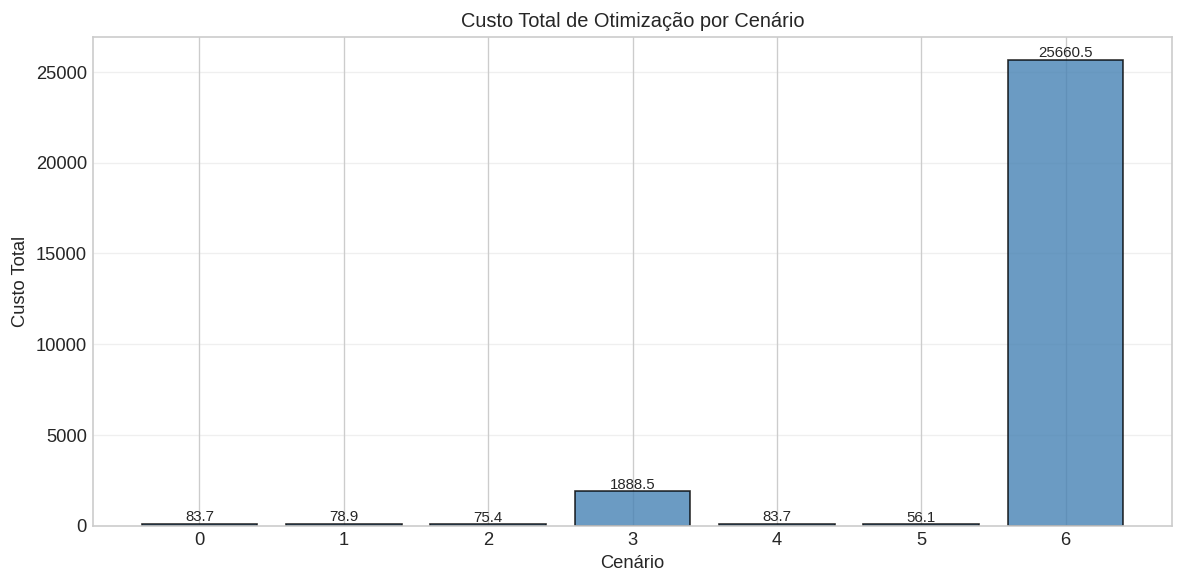

  ✓ Salvo: figuras_artigo/comparativo_custo_total.png


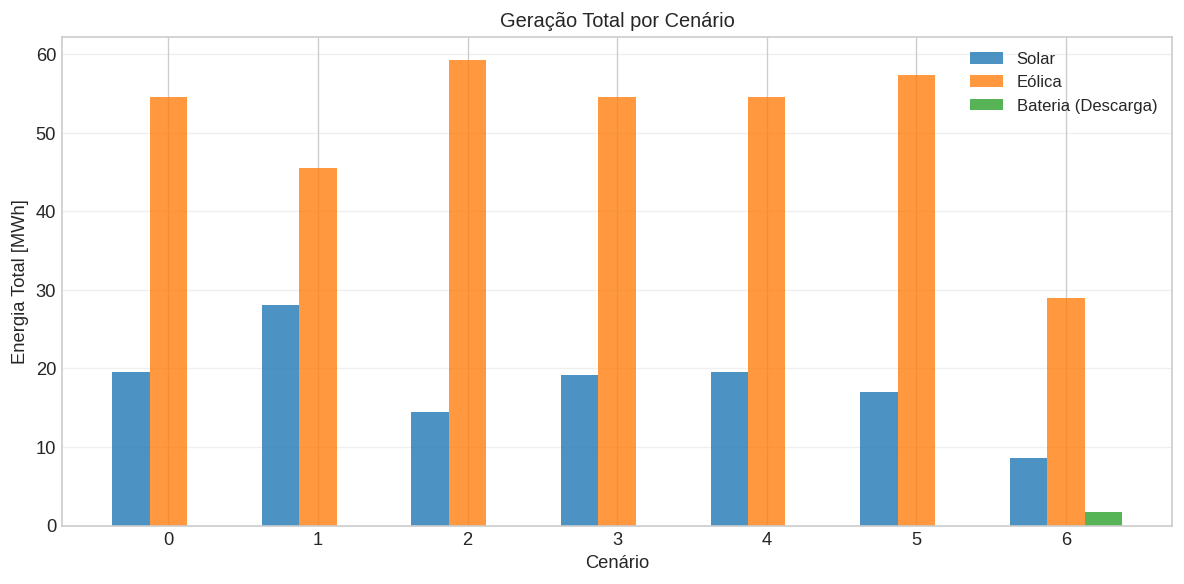

  ✓ Salvo: figuras_artigo/comparativo_geracao.png


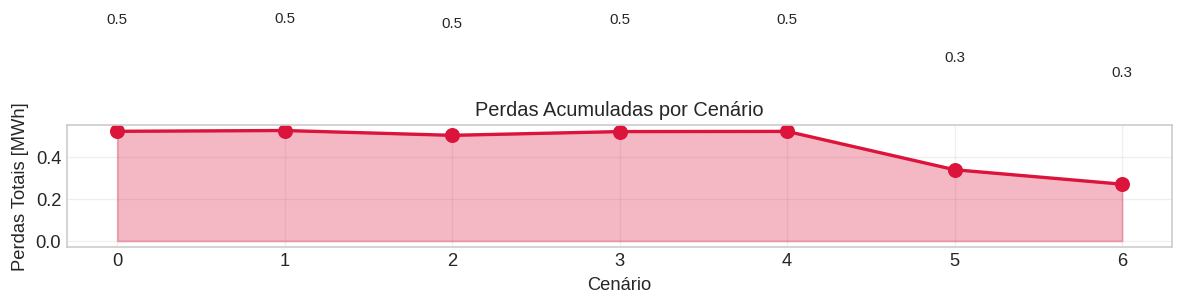

  ✓ Salvo: figuras_artigo/comparativo_perdas.png

✓ Gráficos comparativos gerados com sucesso!


In [31]:
# [EXECUÇÃO] Gerar Tabelas e Gráficos Comparativos
print("Gerando relatório comparativo...\n")

# Gerar tabelas de resumo
gerar_tabelas_resumo(df_metricas)

# Gerar gráficos comparativos
gerar_graficos_comparativos(df_metricas)

In [32]:
# [RELATÓRIO FINAL] Resumo da Análise e Estrutura de Saídas
print("\n" + "="*70)
print("RELATÓRIO FINAL - ANÁLISE DE MÚLTIPLOS CENÁRIOS DE MICRORREDE")
print("="*70 + "\n")

print("📊 ESTRUTURA DE SAÍDAS GERADAS:\n")

print("1. ARQUIVOS CSV:")
print("   └─ variaveis_otimizadas/")
print("      ├─ variaveis_otimizadas_0.csv  (cenário 0)")
print("      ├─ variaveis_otimizadas_1.csv  (cenário 1)")
print("      ├─ ... (cenários 2 até 6)")
print("      └─ variaveis_otimizadas_consolidado.csv  (consolidado com coluna 'cenario')\n")

print("2. PASTAS DE FIGURAS (por cenário):")
print("   └─ figuras_artigo_0/  (cenário 0)")
print("      ├─ fig1_despacho.png")
print("      ├─ fig2_soc_fluxos_perdas.png")
print("      ├─ fig3_acumulado_variaveis.png")
print("      └─ fig4_heatmap_series.png")
print("   ├─ figuras_artigo_1/  (cenário 1)")
print("   ├─ ... (cenários 2 até 6)\n")

print("3. FIGURAS COMPARATIVAS:")
print("   └─ figuras_artigo/")
print("      ├─ comparativo_custo_total.png")
print("      ├─ comparativo_geracao.png")
print("      └─ comparativo_perdas.png\n")

print("="*70)
print("✓ ANÁLISE CONCLUÍDA COM SUCESSO!")
print("="*70 + "\n")

print("💡 PRÓXIMOS PASSOS:")
print("   1. Revise as tabelas de métricas acima")
print("   2. Analise os gráficos comparativos gerados")
print("   3. Consulte as pastas figuras_artigo_X/ para detalhes por cenário")
print("   4. Use variaveis_otimizadas_consolidado.csv para análises adicionais\n")


RELATÓRIO FINAL - ANÁLISE DE MÚLTIPLOS CENÁRIOS DE MICRORREDE

📊 ESTRUTURA DE SAÍDAS GERADAS:

1. ARQUIVOS CSV:
   └─ variaveis_otimizadas/
      ├─ variaveis_otimizadas_0.csv  (cenário 0)
      ├─ variaveis_otimizadas_1.csv  (cenário 1)
      ├─ ... (cenários 2 até 6)
      └─ variaveis_otimizadas_consolidado.csv  (consolidado com coluna 'cenario')

2. PASTAS DE FIGURAS (por cenário):
   └─ figuras_artigo_0/  (cenário 0)
      ├─ fig1_despacho.png
      ├─ fig2_soc_fluxos_perdas.png
      ├─ fig3_acumulado_variaveis.png
      └─ fig4_heatmap_series.png
   ├─ figuras_artigo_1/  (cenário 1)
   ├─ ... (cenários 2 até 6)

3. FIGURAS COMPARATIVAS:
   └─ figuras_artigo/
      ├─ comparativo_custo_total.png
      ├─ comparativo_geracao.png
      └─ comparativo_perdas.png

✓ ANÁLISE CONCLUÍDA COM SUCESSO!

💡 PRÓXIMOS PASSOS:
   1. Revise as tabelas de métricas acima
   2. Analise os gráficos comparativos gerados
   3. Consulte as pastas figuras_artigo_X/ para detalhes por cenário
   4. Use v